# Exploratory Data Analysis (EDA)

**CI/CD Pipeline Failure Prediction** – Single source-of-truth EDA notebook.

### Notebook Outline
1. Environment Setup & Data Loading
2. Column Data Dictionary – what every feature means
3. Unique Values & Cardinality Analysis
4. Missing Values Analysis
5. Column Drop Recommendations
6. Target Variable Distribution (`tr_status`)
7. Key Numerical Features – Distributions
8. Feature Correlation Analysis
9. Final Recommendations & Next Steps


## 1. Environment Setup & Data Loading


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', 100)

data_path = '../data/cleaned_data.csv'
df = pd.read_csv(data_path, nrows=250_000, low_memory=False)

print(f'Rows : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
df.info()


Rows : 250,000
Columns: 47

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 47 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   gh_project_name                    250000 non-null  str    
 1   gh_is_pr                           250000 non-null  bool   
 2   gh_pr_created_at                   250000 non-null  str    
 3   gh_pull_req_num                    250000 non-null  float64
 4   gh_lang                            250000 non-null  str    
 5   git_merged_with                    250000 non-null  str    
 6   git_branch                         250000 non-null  str    
 7   git_prev_commit_resolution_status  250000 non-null  str    
 8   tr_prev_build                      250000 non-null  float64
 9   gh_team_size                       250000 non-null  int64  
 10  git_num_all_built_commits          250000 non-null  int64  
 11  gh_num_issue_comments 

In [32]:
df['tr_status'].unique()

<StringArray>
['passed', 'failed', 'errored']
Length: 3, dtype: str

In [33]:
df.head(10)


,gh_project_name,gh_is_pr,gh_pr_created_at,gh_pull_req_num,gh_lang,git_merged_with,git_branch,git_prev_commit_resolution_status,tr_prev_build,gh_team_size,git_num_all_built_commits,gh_num_issue_comments,gh_num_commit_comments,gh_num_pr_comments,git_diff_src_churn,git_diff_test_churn,gh_diff_files_added,gh_diff_files_deleted,gh_diff_files_modified,gh_diff_tests_added,gh_diff_tests_deleted,gh_diff_src_files,gh_diff_doc_files,gh_diff_other_files,gh_num_commits_on_files_touched,gh_sloc,gh_test_lines_per_kloc,gh_test_cases_per_kloc,gh_asserts_cases_per_kloc,gh_by_core_team_member,gh_build_started_at,gh_repo_age,gh_repo_num_commits,tr_build_number,tr_log_lan,tr_log_status,tr_log_analyzer,tr_log_frameworks,tr_log_bool_tests_ran,tr_log_bool_tests_failed,tr_log_num_tests_ok,tr_log_num_tests_failed,tr_log_num_tests_run,tr_log_num_tests_skipped,tr_log_testduration,tr_duration,tr_status
0,rspec/rspec-core,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,114.83,956.0,passed
1,rspec/rspec-core,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,171.37,956.0,passed
2,rspec/rspec-core,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,177.02,956.0,passed
3,rspec/rspec-core,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,182.05,956.0,passed
4,rspec/rspec-core,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,31,202,0.0,0,0.0,117,0,34,6,137,0,0,3,0,148,817,3094,1539.431157,163.865546,225.921138,False,2011-04-16 11:24:39,655.82,1139,23,ruby,unknown,ruby,rspec#cucumber,True,False,800.0,0.0,800.0,2.0,113.26,956.0,passed
5,ruby-amqp/amqp,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,6,8,0.0,1,0.0,2,0,1,0,9,0,0,1,0,9,194,1592,804.648241,50.251256,90.452261,True,2011-04-16 17:37:39,1009.77,767,19,ruby,unknown,ruby,rspec,True,False,82.0,0.0,82.0,8.0,31.61,391.0,passed
6,ruby-amqp/amqp,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,6,8,0.0,1,0.0,2,0,1,0,9,0,0,1,0,9,194,1592,804.648241,50.251256,90.452261,True,2011-04-16 17:37:39,1009.77,767,19,ruby,unknown,ruby,rspec,True,False,82.0,0.0,82.0,8.0,31.04,391.0,passed
7,ruby-amqp/amqp,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,6,8,0.0,1,0.0,2,0,1,0,9,0,0,1,0,9,194,1592,804.648241,50.251256,90.452261,True,2011-04-16 17:37:39,1009.77,767,19,ruby,unknown,ruby,rspec,True,False,82.0,0.0,82.0,8.0,31.15,391.0,passed
8,ruby-amqp/amqp,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,6,8,0.0,1,0.0,2,0,1,0,9,0,0,1,0,9,194,1592,804.648241,50.251256,90.452261,True,2011-04-16 17:37:39,1009.77,767,19,ruby,unknown,ruby,rspec,True,False,82.0,0.0,82.0,8.0,30.92,391.0,passed
9,ruby-amqp/amqp,False,unknown,0.0,ruby,unknown,master,merge_found,0.0,6,8,0.0,1,0.0,2,0,1,0,9,0,0,1,0,9,194,1592,804.648241,50.251256,90.452261,True,2011-04-16 17:37:39,1009.77,767,19,ruby,unknown,ruby,rspec,True,False,82.0,0.0,82.0,8.0,34.60,391.0,passed


In [34]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gh_project_name,250000,299,spree/spree,16187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gh_is_pr,250000,2,False,225891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gh_pr_created_at,250000,7500,unknown,225891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gh_pull_req_num,250000.0,NaN,NaN,NaN,58.647888,249.445085,0.0,0.0,0.0,0.0,2285.0
gh_lang,250000,4,ruby,176209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
git_merged_with,250000,3,unknown,226083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
git_branch,250000,2206,master,197958,NaN,NaN,NaN,NaN,NaN,NaN,NaN
git_prev_commit_resolution_status,250000,3,build_found,194342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tr_prev_build,250000.0,NaN,NaN,NaN,2432327.520596,2300721.62605,0.0,39631.0,1942790.0,4376585.0,7175800.0
gh_team_size,250000.0,NaN,NaN,NaN,19.249296,18.040516,0.0,6.0,13.0,25.0,140.0


## 2. Column Data Dictionary

Before any analysis it is essential to **understand what every column represents**. The dataset originates from the TravisTorrent project and captures metadata about GitHub repositories, git history, and Travis CI builds.

### GitHub / Repository Columns
| Column | Description |
|--------|-------------|
| `gh_project_name` | Full `owner/repo` name of the GitHub project. |
| `gh_lang` | Primary programming language (e.g. *ruby*, *java*). |
| `gh_team_size` | Number of unique contributors at build time. |
| `gh_sloc` | Source Lines of Code in the repo at build time. |
| `gh_repo_age` | Age of the repository in days. |
| `gh_repo_num_commits` | Total commits in the repo up to this build. |
| `gh_by_core_team_member` | Whether the committer is a core team member. |
| `gh_description_complexity` | Complexity metric of the project description (often missing). |

### Pull Request Columns
| Column | Description |
|--------|-------------|
| `gh_is_pr` | Whether this build was triggered by a pull request. |
| `gh_pr_created_at` | Timestamp when the PR was created (NaN if not a PR). |
| `gh_pull_req_num` | The pull request number. |
| `gh_num_issue_comments` | Number of issue-level comments on the PR. |
| `gh_num_commit_comments` | Number of commit-level comments. |
| `gh_num_pr_comments` | Number of review-level comments on the PR. |

### Git Diff / Commit Columns
| Column | Description |
|--------|-------------|
| `git_merged_with` | Merge strategy used (often missing). |
| `git_branch` | Branch that was built (e.g. *master*). |
| `gh_num_commits_in_push` | Commits in the push event (100 % missing). |
| `gh_commits_in_push` | List of commit SHAs in the push (100 % missing). |
| `git_prev_commit_resolution_status` | How the previous commit was resolved. |
| `git_prev_built_commit` | SHA of the previously built commit. |
| `git_all_built_commits` | All commit SHAs included in this build. |
| `git_num_all_built_commits` | Count of commits included in this build. |
| `git_trigger_commit` | SHA of the commit that triggered the build. |
| `git_diff_src_churn` | Lines changed in **source** files. |
| `git_diff_test_churn` | Lines changed in **test** files. |
| `gh_diff_files_added` | Files added in the diff. |
| `gh_diff_files_deleted` | Files deleted in the diff. |
| `gh_diff_files_modified` | Files modified in the diff. |
| `gh_diff_tests_added` | Test cases added. |
| `gh_diff_tests_deleted` | Test cases deleted. |
| `gh_diff_src_files` | Source files touched. |
| `gh_diff_doc_files` | Documentation files touched. |
| `gh_diff_other_files` | Other files touched. |
| `gh_num_commits_on_files_touched` | Historic commits on files touched (proxy for file hotness). |

### Code Quality / Testing Metrics
| Column | Description |
|--------|-------------|
| `gh_test_lines_per_kloc` | Test lines per 1 000 LOC. |
| `gh_test_cases_per_kloc` | Test cases per 1 000 LOC. |
| `gh_asserts_cases_per_kloc` | Assertions per 1 000 LOC. |

### Timestamp Columns
| Column | Description |
|--------|-------------|
| `gh_first_commit_created_at` | Timestamp of the first commit (100 % missing). |
| `gh_pushed_at` | Timestamp of the push event (100 % missing). |
| `gh_build_started_at` | Timestamp when the CI build started. |

### Travis CI Build / Job Columns
| Column | Description |
|--------|-------------|
| `tr_build_id` | Unique Travis CI build ID. |
| `tr_prev_build` | Build ID of the previous build. |
| `tr_virtual_merged_into` | SHA the PR was virtually merged into. |
| `tr_job_id` | Unique Travis CI job ID (one build has many jobs). |
| `tr_build_number` | Sequential build number inside the project. |
| `tr_original_commit` | Original commit SHA recorded by Travis. |
| `tr_duration` | Total build duration in seconds. |
| `tr_jobs` | List of job IDs belonging to this build. |

### Travis CI Log Columns
| Column | Description |
|--------|-------------|
| `tr_log_lan` | Language detected from the build log. |
| `tr_log_status` | Build status from the log (`ok`, `broken`, `unknown`, etc.). |
| `tr_log_setup_time` | Setup time from the log (almost 100 % missing). |
| `tr_log_analyzer` | Log analyzer used (e.g. *ruby*, *java-gradle*). |
| `tr_log_frameworks` | Testing frameworks detected (e.g. *rspec#cucumber*). |
| `tr_log_bool_tests_ran` | Whether tests were run. |
| `tr_log_bool_tests_failed` | Whether any test failed. |
| `tr_log_num_tests_ok` | Number of tests passed. |
| `tr_log_num_tests_failed` | Number of tests failed. |
| `tr_log_num_tests_run` | Total tests executed. |
| `tr_log_num_tests_skipped` | Tests skipped. |
| `tr_log_num_test_suites_run` | Test suites run (~100 % missing). |
| `tr_log_num_test_suites_ok` | Test suites passed (~100 % missing). |
| `tr_log_num_test_suites_failed` | Test suites failed (~100 % missing). |
| `tr_log_tests_failed` | Names/paths of failed tests (~97 % missing). |
| `tr_log_testduration` | Duration of the test phase in seconds. |
| `tr_log_buildduration` | Duration of the full build (~99 % missing). |

### Target Column
| Column | Description |
|--------|-------------|
| `tr_status` | **Target variable** – `passed`, `failed`, or `errored`. |


## 3. Unique Values & Cardinality Analysis

For every column we compute **dtype**, **non-null count**, **null %**, **number of unique values**, and a **few sample values**.

This helps spot:
- **Constant columns** (1 unique value) – useless for prediction.
- **ID-like columns** (unique values ≈ row count) – commit SHAs, job IDs.
- **Low-cardinality categoricals** (2–10 values) – great candidates for encoding.


In [35]:
records = []
for col in df.columns:
    non_null = df[col].notna().sum()
    null_pct = round(df[col].isna().sum() / len(df) * 100, 2)
    nuniq    = df[col].nunique(dropna=True)
    samples  = df[col].dropna().unique()[:5].tolist()
    records.append({
        'column': col, 'dtype': str(df[col].dtype),
        'non_null': non_null, 'null_%': null_pct,
        'nunique': nuniq, 'sample_values': str(samples)
    })

cardinality_df = pd.DataFrame(records)

# Color-coded display
display(cardinality_df.style
    .background_gradient(subset=['null_%'], cmap='Reds')
    .background_gradient(subset=['nunique'], cmap='Blues')
    .set_caption('Column Cardinality & Uniqueness Report'))


,column,dtype,non_null,null_%,nunique,sample_values
0,gh_project_name,str,250000,0.000000,299,"['rspec/rspec-core', 'ruby-amqp/amqp', 'rspec/rspec-mocks', 'rspec/rspec-expectations', 'intridea/multi_json']"
1,gh_is_pr,bool,250000,0.000000,2,"[False, True]"
2,gh_pr_created_at,str,250000,0.000000,7500,"['unknown', '2012-06-18 12:37:21', '2012-06-19 07:45:54', '2012-06-19 08:34:16', '2012-06-12 18:41:33']"
3,gh_pull_req_num,float64,250000,0.000000,1862,"[0.0, 71.0, 603.0, 604.0, 293.0]"
4,gh_lang,str,250000,0.000000,4,"['ruby', 'java', 'python', 'go']"
5,git_merged_with,str,250000,0.000000,3,"['unknown', 'merge_button', 'commits_in_master']"
6,git_branch,str,250000,0.000000,2206,"['master', '0.7.x-stable', 'documentation_improvements', 'pry', '2-6-maintenance']"
7,git_prev_commit_resolution_status,str,250000,0.000000,3,"['merge_found', 'build_found', 'no_previous_build']"
8,tr_prev_build,float64,250000,0.000000,56135,"[0.0, 3154.0, 3233.0, 3239.0, 3211.0]"
9,gh_team_size,int64,250000,0.000000,109,"[31, 6, 32, 17, 21]"


### Interpretation Guide

| Scenario | Meaning | Action |
|----------|---------|--------|
| `null_% ≈ 100` | Column is almost entirely empty | **Drop** |
| `nunique = 1` | Constant – same value in every row | **Drop** |
| `nunique ≈ n_rows` | Essentially a unique ID (commit SHAs, job IDs) | **Drop** |
| Low `nunique` (2-10) for string columns | Useful categorical feature | **Keep & Encode** |
| `null_%` between 50-90 | Partially missing | **Investigate – impute or drop** |


## 4. Missing Values Analysis

Columns with very high missing rates (> 90 %) generally carry no predictive power and can introduce noise. We visualize them with a 90 % threshold line.


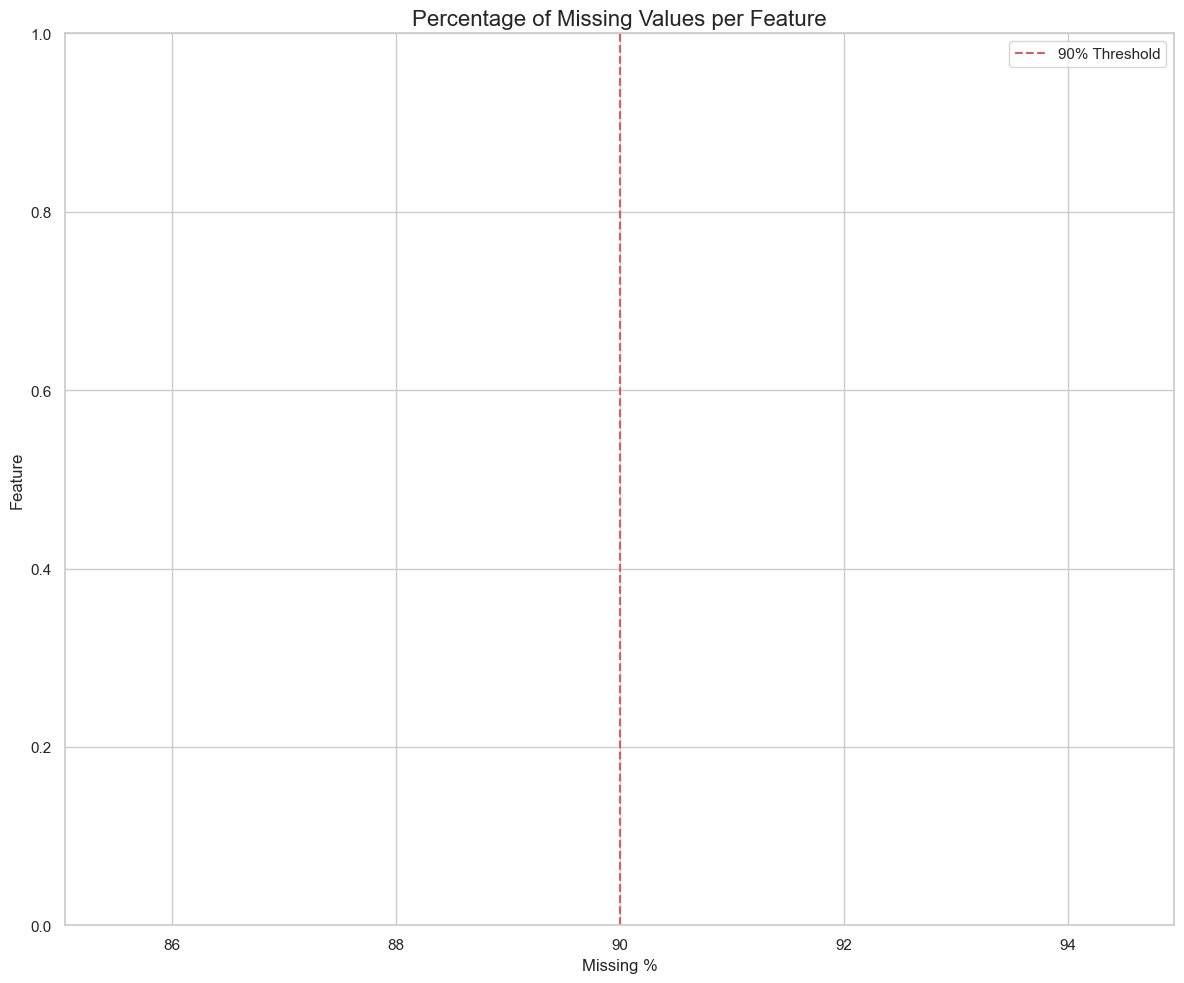

Top 10 columns with highest missing data:
Series([], dtype: float64)


In [36]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='mako')
plt.axvline(x=90, color='r', linestyle='--', label='90% Threshold')
plt.title('Percentage of Missing Values per Feature', fontsize=16)
plt.xlabel('Missing %')
plt.ylabel('Feature')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 columns with highest missing data:')
print(missing_pct.head(10))


## 5. Column Drop Recommendations

We automatically flag columns for removal based on these rules:

1. **>= 90 % missing** – too sparse to carry reliable signal.
2. **Only 1 unique value** – constant; zero variance.
3. **Unique ratio >= 95 %** (`nunique / non_null`) – essentially an ID column.
4. **Known list / free-text columns** – `tr_jobs`, `git_all_built_commits`, `tr_log_tests_failed`, etc.


In [37]:
# THRESHOLD_MISSING  = 90.0
# THRESHOLD_ID_RATIO = 0.95
# KNOWN_DROP = {'tr_jobs','gh_commits_in_push','git_all_built_commits','tr_log_tests_failed'}

# drop_reasons = []
# for _, row in cardinality_df.iterrows():
#     col, null_p, nuniq, non_n = row['column'], row['null_%'], row['nunique'], row['non_null']
#     reasons = []
#     if null_p >= THRESHOLD_MISSING:
#         reasons.append(f'Missing {null_p}%')
#     if nuniq <= 1:
#         reasons.append('Constant')
#     if non_n > 0 and nuniq / non_n >= THRESHOLD_ID_RATIO:
#         reasons.append(f'ID-like ({nuniq/non_n:.1%} unique)')
#     if col in KNOWN_DROP:
#         reasons.append('List / free-text')
#     if reasons:
#         drop_reasons.append({'column': col, 'reason': ' | '.join(reasons)})

# drop_df = pd.DataFrame(drop_reasons)
# print(f'Columns to DROP : {len(drop_df)} / {len(df.columns)}')
# display(drop_df)

# keep_cols = [c for c in df.columns if c not in drop_df['column'].values]
# print(f'\nColumns to KEEP : {len(keep_cols)}')
# print(keep_cols)


### Summary

After pruning we retain **fewer, higher-quality features**, which will:
- **Reduce noise** that confuses models.
- **Speed up training** (fewer dimensions).
- **Improve interpretability** of predictions.


## 6. Target Variable Distribution (`tr_status`)

Understanding class imbalance is critical. If `passed` vastly outnumbers `failed`/`errored`, techniques like SMOTE or class-weighting will be needed.


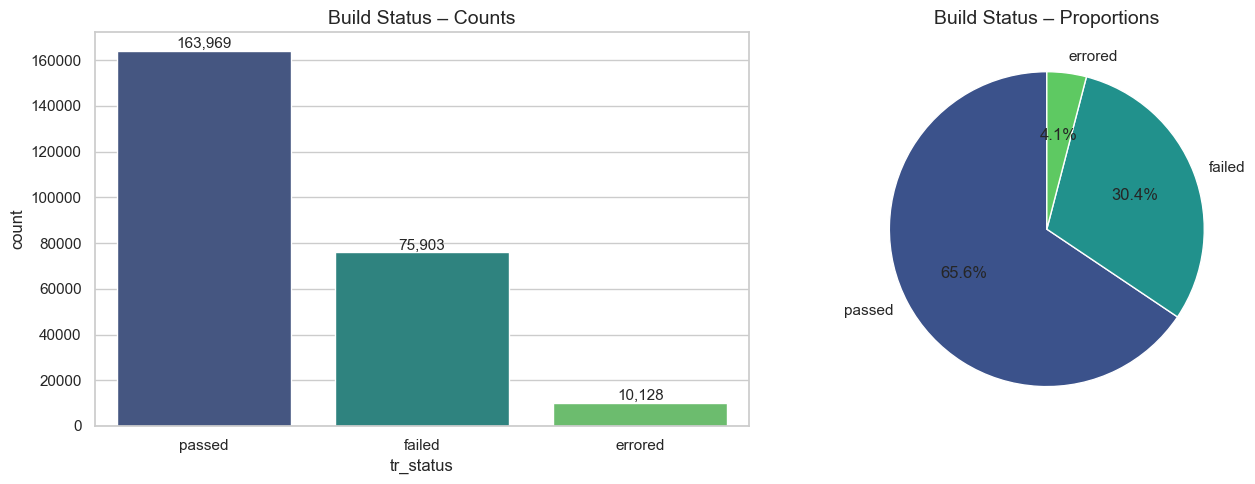

Value counts:
tr_status
passed     163969
failed      75903
errored     10128
Name: count, dtype: int64

Class ratios:
tr_status
passed     65.59
failed     30.36
errored     4.05
Name: proportion, dtype: float64


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
order = df['tr_status'].value_counts().index
sns.countplot(x='tr_status', data=df, order=order, palette='viridis', ax=axes[0])
axes[0].set_title('Build Status – Counts', fontsize=14)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
df['tr_status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,
                                        colors=sns.color_palette('viridis', len(order)),
                                        ax=axes[1])
axes[1].set_ylabel('')
axes[1].set_title('Build Status – Proportions', fontsize=14)

plt.tight_layout()
plt.show()

print('Value counts:')
print(df['tr_status'].value_counts())
print()
print('Class ratios:')
print(round(df['tr_status'].value_counts(normalize=True) * 100, 2))


## 7. Key Numerical Features – Distributions

We examine the distributions of the most important numerical features to check for **skewness**, **outliers**, and **scale differences** that will affect model training.


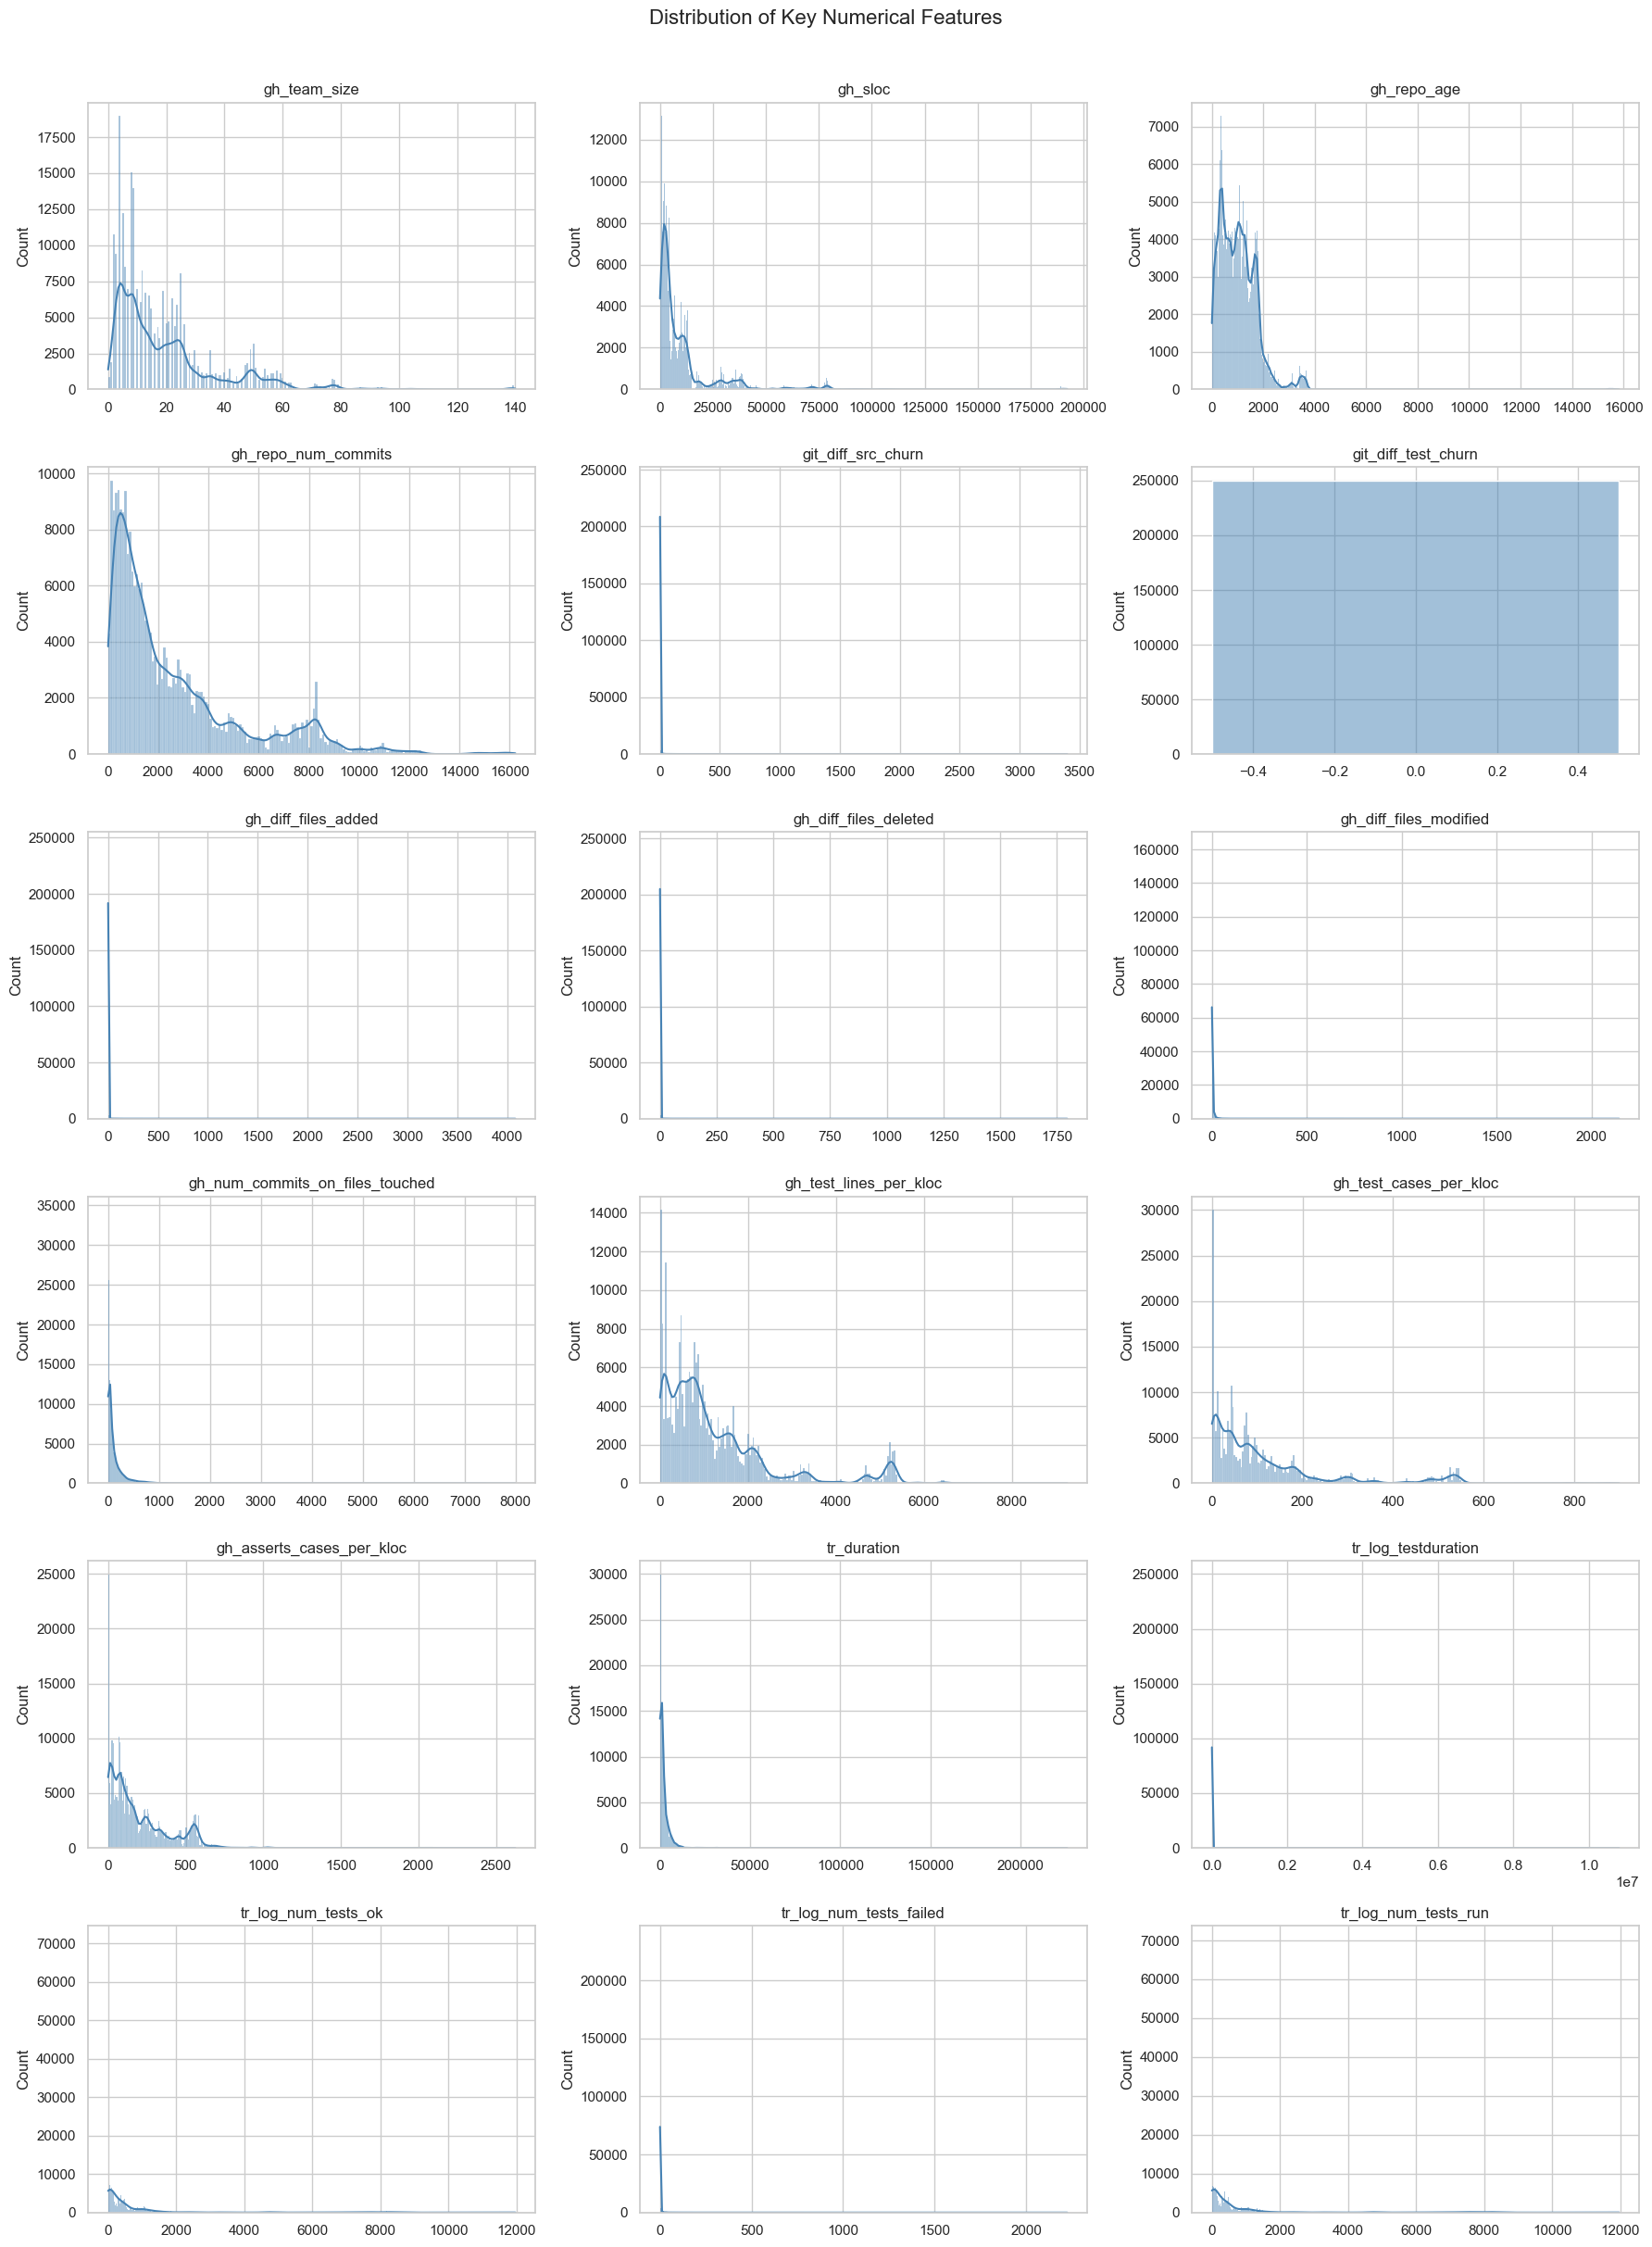

In [39]:
num_features = [
    'gh_team_size', 'gh_sloc', 'gh_repo_age', 'gh_repo_num_commits',
    'git_diff_src_churn', 'git_diff_test_churn',
    'gh_diff_files_added', 'gh_diff_files_deleted', 'gh_diff_files_modified',
    'gh_num_commits_on_files_touched',
    'gh_test_lines_per_kloc', 'gh_test_cases_per_kloc', 'gh_asserts_cases_per_kloc',
    'tr_duration', 'tr_log_testduration',
    'tr_log_num_tests_ok', 'tr_log_num_tests_failed', 'tr_log_num_tests_run',
]
# Keep only columns that exist in the dataframe
num_features = [c for c in num_features if c in df.columns]

n = len(num_features)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    sns.histplot(df[feat].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Numerical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


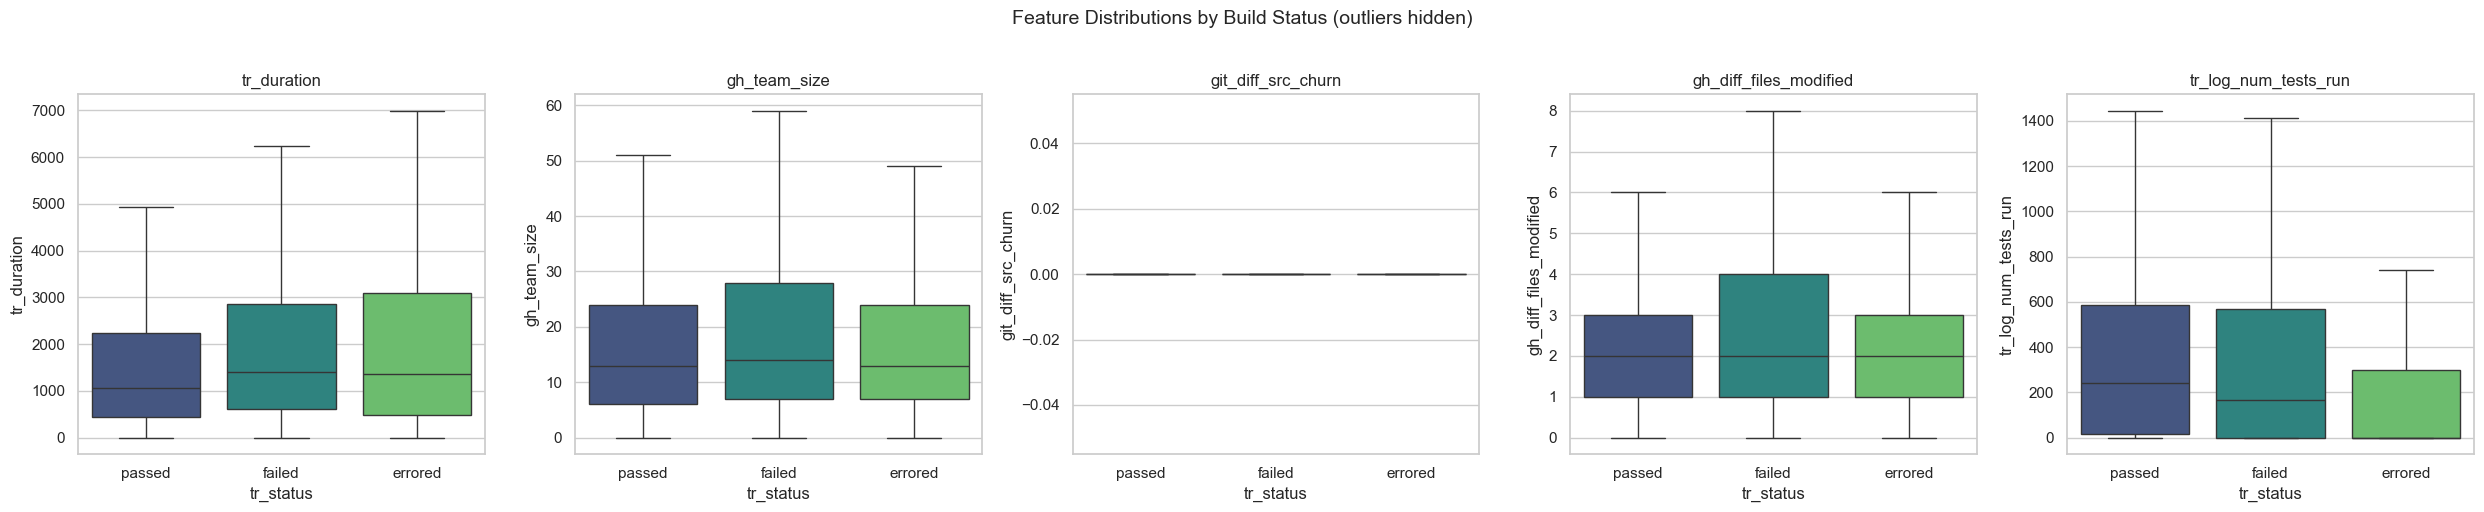

In [40]:
# Box-plots by target to see how features differ between passed / failed
box_features = ['tr_duration', 'gh_team_size', 'git_diff_src_churn',
                'gh_diff_files_modified', 'tr_log_num_tests_run']
box_features = [c for c in box_features if c in df.columns]

fig, axes = plt.subplots(1, len(box_features), figsize=(5*len(box_features), 5))
if len(box_features) == 1: axes = [axes]

for i, feat in enumerate(box_features):
    sns.boxplot(x='tr_status', y=feat, data=df, palette='viridis',
                ax=axes[i], showfliers=False)
    axes[i].set_title(feat, fontsize=12)

plt.suptitle('Feature Distributions by Build Status (outliers hidden)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 8. Feature Correlation Analysis

We compute the Pearson correlation matrix for all numeric features.  
- **Highly correlated pairs** (|r| > 0.9) are candidates for removal (redundant information).  
- **Moderate correlations with the target** help identify the strongest predictors.


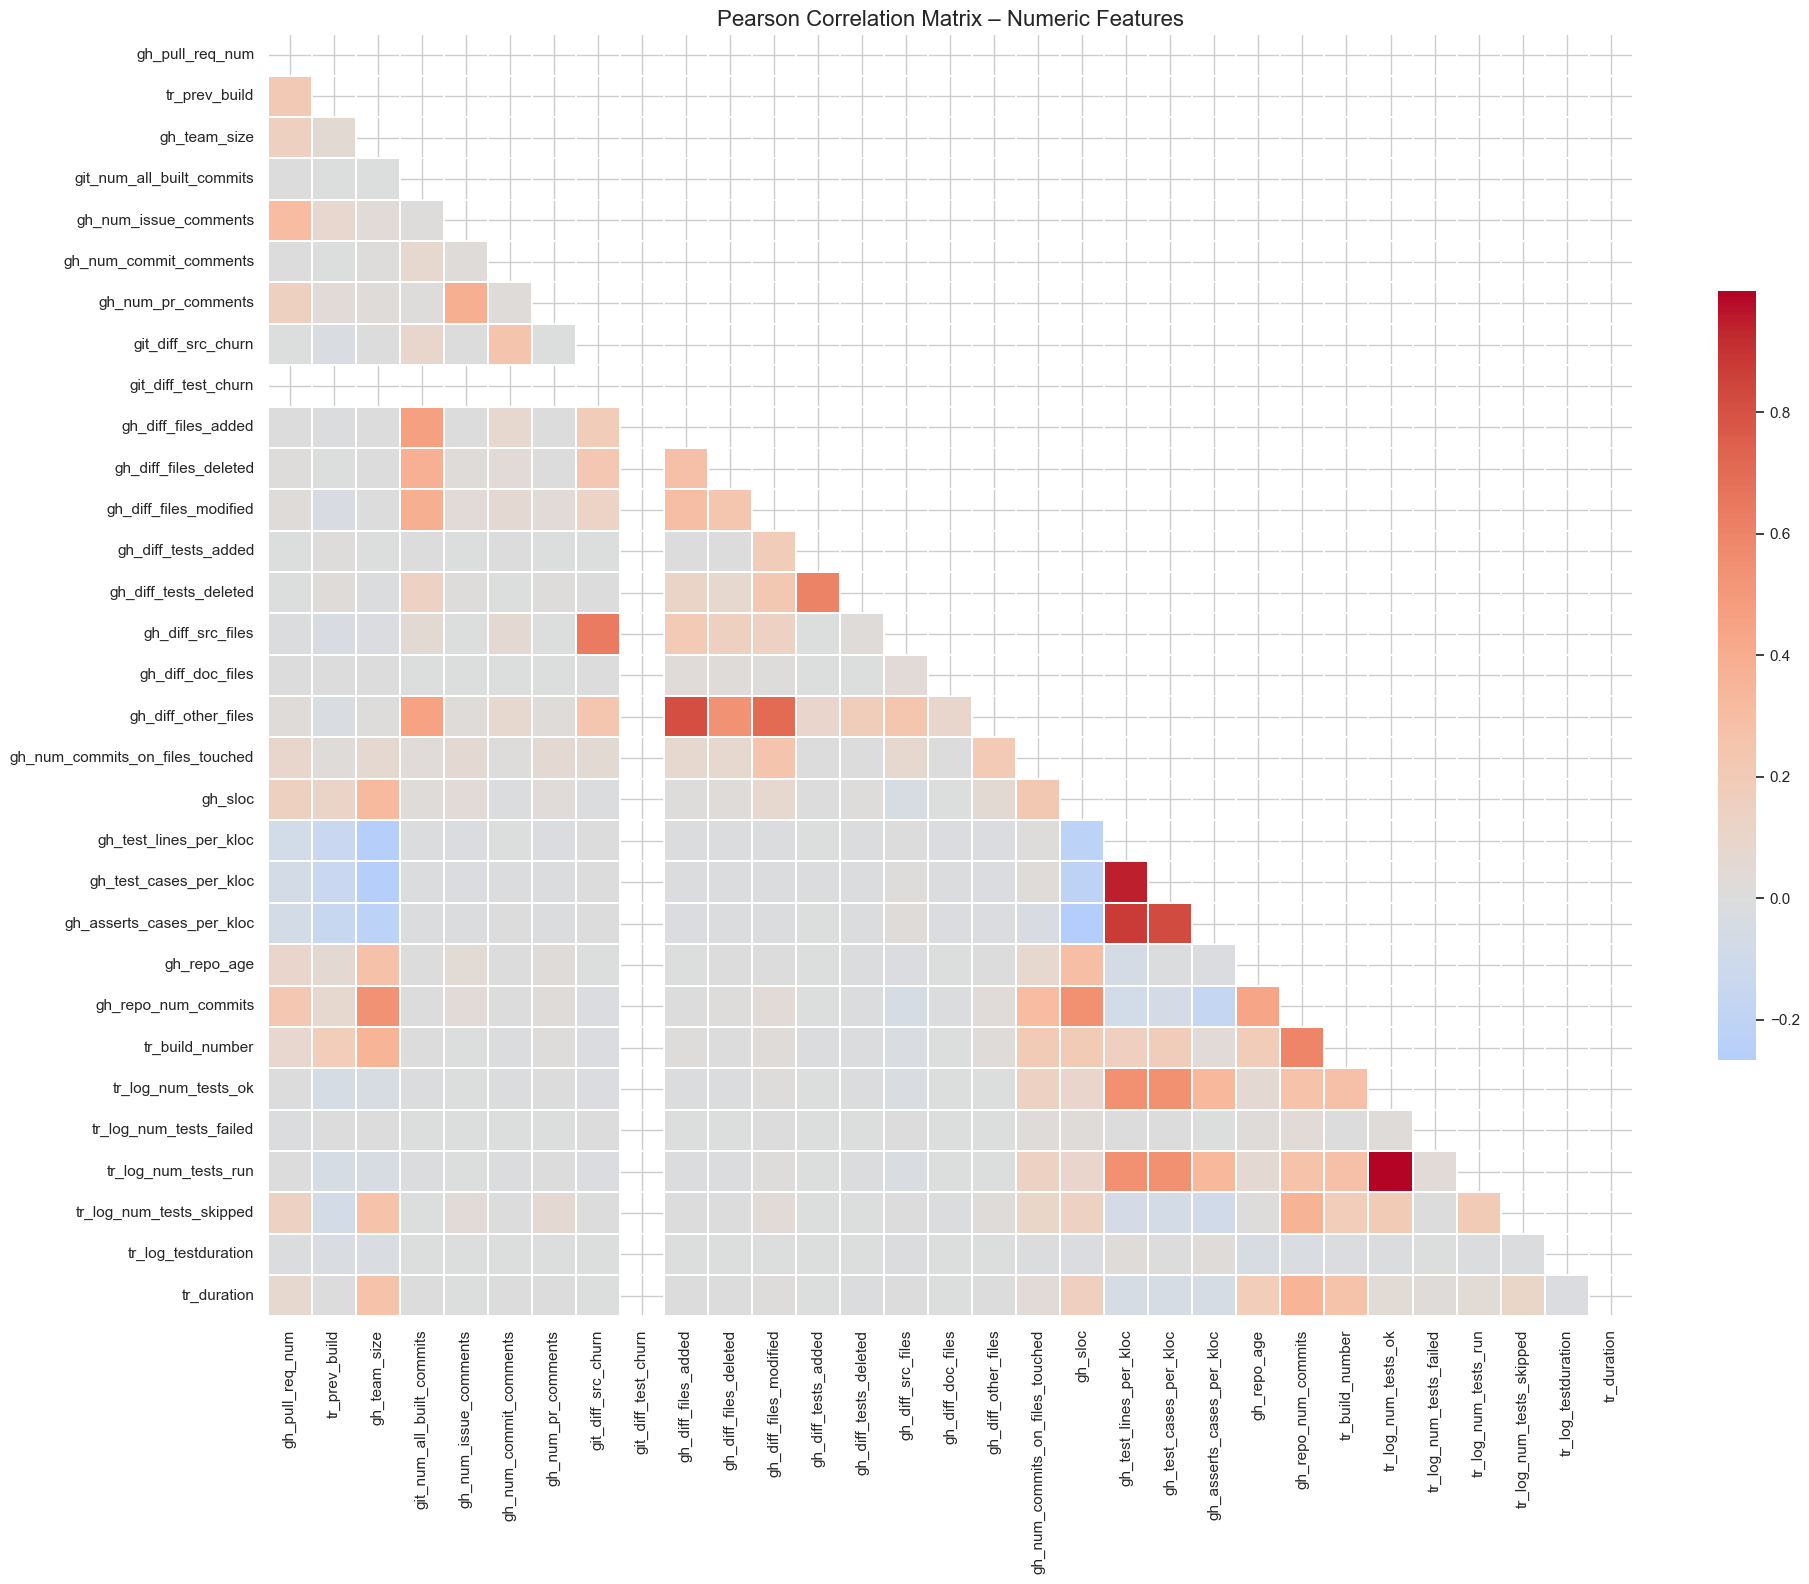

In [41]:
numeric_df = df.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, fmt='.2f',
            cbar_kws={'shrink': 0.6})
plt.title('Pearson Correlation Matrix – Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()


In [42]:
# Find highly correlated pairs (|r| > 0.90)
threshold = 0.90
upper = corr.where(mask == False)
high_corr = [
    (col1, col2, round(upper.loc[col1, col2], 3))
    for col1 in upper.columns
    for col2 in upper.columns
    if col1 != col2 and abs(upper.loc[col1, col2]) > threshold
]
high_corr_df = pd.DataFrame(high_corr, columns=['Feature_1', 'Feature_2', 'Correlation'])
high_corr_df = high_corr_df.drop_duplicates(subset=['Correlation']).sort_values('Correlation', key=abs, ascending=False)

print(f'Highly correlated pairs (|r| > {threshold}):')
display(high_corr_df)


Highly correlated pairs (|r| > 0.9):


,Feature_1,Feature_2,Correlation
1,tr_log_num_tests_run,tr_log_num_tests_ok,1.000
0,gh_test_cases_per_kloc,gh_test_lines_per_kloc,0.942


## 9. Final Recommendations & Next Steps

### Key Findings

1. **Class Imbalance** – The target `tr_status` is heavily skewed toward `passed`. Techniques such as **SMOTE**, **class weighting**, or **under-sampling** should be applied during model training.

2. **Columns to Drop** – We identified a significant number of columns that are either:
   - Almost 100 % missing (e.g. `gh_first_commit_created_at`, `gh_pushed_at`, `gh_num_commits_in_push`, `gh_commits_in_push`)
   - Constant
   - ID-like (commit SHAs, job IDs) that would cause over-fitting
   - Free-text / list columns not directly usable as ML features

3. **Skewed Distributions** – Most numerical features are heavily right-skewed. Consider **log transforms** or **robust scaling** before feeding into models.

4. **High Correlations** – Some feature pairs have |r| > 0.90. During feature engineering, consider **dropping one of each pair** to reduce multi-collinearity.

5. **Feature Engineering Ideas**:
   - Convert `gh_build_started_at` to time-based features (hour of day, day of week)
   - Create ratios like `tests_failed / tests_run`
   - Encode low-cardinality categoricals (`gh_lang`, `tr_log_lan`, `git_branch`, etc.)

### Next Steps

| Step | Description |
|------|-------------|
| **Data Cleaning** | Apply the column drops identified above, handle remaining missing values |
| **Feature Engineering** | Create new features, encode categoricals, apply transformations |
| **Modelling** | Train baseline models, apply SMOTE, tune hyper-parameters |
| **Evaluation** | Use F1-score / AUC-ROC (accuracy alone is misleading with imbalanced data) |
